In [3]:
import particles
from sir_PMCMC import ChainBinomialModel
from sir_PMCMC import ScalarStructDist
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from particles import distributions as dists
from particles import state_space_models as ssm
from particles.collectors import Moments
from particles import mcmc
from collections import OrderedDict


# Simulate SIR epidemic in Particles

In [4]:
model = ChainBinomialModel(N = 10000, beta = 0.3, gamma = 0.1, rho = 0.25, phi = 2, n_i =10)
x, y = model.simulate(100)

TypeError: ChainBinomialModel.__init__() got an unexpected keyword argument 'beta'

# Plot SIR epidemic progression in Matplotlib

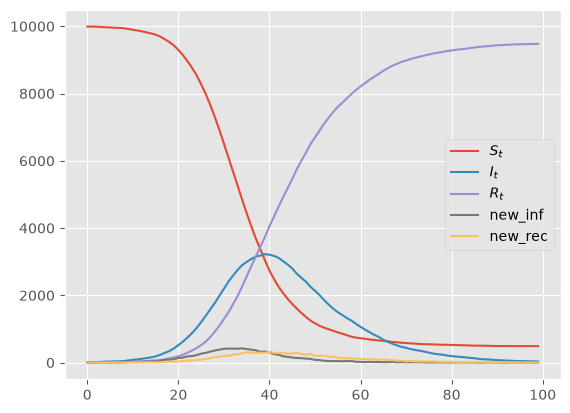

In [ ]:
# Plot count of new infections, new recoveries, susceptibles, infectious, and removed
plt.style.use('ggplot')
plt.plot([xt['S'] for xt in x], label=r'$S_t$')
plt.plot([xt['I'] for xt in x], label=r'$I_t$')
plt.plot([xt['R'] for xt in x], label=r'$R_t$')
plt.plot([xt['new_inf'] for xt in x], label='new_inf')
plt.plot([xt['new_rec'] for xt in x], label='new_rec')
plt.legend()

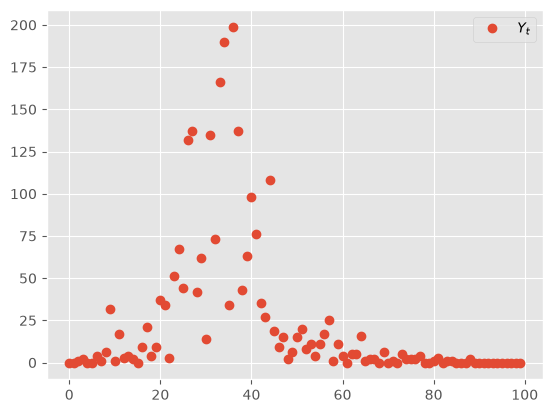

In [ ]:
# Plot the observation model
plt.style.use('ggplot')
plt.plot(y, label=r'$Y_t$', linestyle='', marker='o')

plt.legend()

# DataFrames & csv files

In [ ]:
simulation_df = pd.DataFrame(np.concatenate(x))
print(simulation_df)

    new_inf  new_rec       S     I       R
0       0.0      0.0  9990.0  10.0     0.0
1       0.0      0.0  9990.0  10.0     0.0
2       3.0      0.0  9987.0  13.0     0.0
3      10.0      2.0  9977.0  21.0     2.0
4       8.0      0.0  9969.0  29.0     2.0
..      ...      ...     ...   ...     ...
95      0.0      2.0   490.0  46.0  9464.0
96      0.0      3.0   490.0  43.0  9467.0
97      0.0      4.0   490.0  39.0  9471.0
98      1.0      3.0   489.0  37.0  9474.0
99      0.0      4.0   489.0  33.0  9478.0

[100 rows x 5 columns]


In [ ]:
observation_df = pd.DataFrame(np.concatenate(y))
observation_df = observation_df.rename(columns={0: 'observations'})
print(observation_df)

    observations
0              0
1              0
2              1
3              2
4              0
..           ...
95             0
96             0
97             0
98             0
99             0

[100 rows x 1 columns]


In [ ]:
# Save to csv - commented out until needed

"""simulation_df.to_csv('sir_simulation.csv', index=False)
observation_df.to_csv('sir_observation.csv', index=False)"""

"simulation_df.to_csv('sir_simulation.csv', index=False)\nobservation_df.to_csv('sir_observation.csv', index=False)"

# Sequential Monte Carlo

In [ ]:
fk = ssm.Bootstrap(ssm=model, data=y)
alg = particles.SMC(fk=fk, 
                    N=5000,
                    resampling = 'systematic', 
                    verbose=True)
alg.run()

t=0: resample:False, ESS (end of iter)=5000.00
t=1: resample:False, ESS (end of iter)=4577.38
t=2: resample:False, ESS (end of iter)=4376.80
t=3: resample:False, ESS (end of iter)=3963.57
t=4: resample:False, ESS (end of iter)=3453.09
t=5: resample:False, ESS (end of iter)=2676.03
t=6: resample:False, ESS (end of iter)=2663.13
t=7: resample:False, ESS (end of iter)=2453.13
t=8: resample:True, ESS (end of iter)=3914.45
t=9: resample:False, ESS (end of iter)=220.19
t=10: resample:True, ESS (end of iter)=4444.19
t=11: resample:False, ESS (end of iter)=4188.43
t=12: resample:False, ESS (end of iter)=4062.17
t=13: resample:False, ESS (end of iter)=3723.19
t=14: resample:False, ESS (end of iter)=2961.96
t=15: resample:False, ESS (end of iter)=1895.47
t=16: resample:True, ESS (end of iter)=4894.52
t=17: resample:False, ESS (end of iter)=4889.38
t=18: resample:False, ESS (end of iter)=4408.67
t=19: resample:False, ESS (end of iter)=3815.01
t=20: resample:False, ESS (end of iter)=4123.67
t=21: 

# Priors

In [ ]:
prior_dict = {'beta': dists.Uniform(a=0.1, b=0.4),
              'gamma': dists.Uniform(a= 0.05, b= 0.15)}  # Uniform distribution because the prior is uninformative

my_prior = ScalarStructDist(prior_dict)      # need this because 'dict' object has no attribute 'dtype' but StructDist does

# PMMH

In [ ]:
pmmh = mcmc.PMMH(ssm_cls= ChainBinomialModel, prior = my_prior, data=y, Nx=5000, niter=1000, adaptive=True)
pmmh.run()

AttributeError: 'ChainBinomialModel' object has no attribute 'rho'